In [27]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field

In [28]:
load_dotenv()

True

In [29]:
model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

In [30]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description="Sentiment of the review")

In [31]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal['product', 'service', 'other'] = Field(description="Type of issue in the review")
    tone: Literal['angry', 'sad', 'neutral'] = Field(description="Tone of the review")
    urgency: Literal['high', 'medium', 'low'] = Field(description="Urgency of the review")

In [32]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [ ]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagonosis: str
    response: str

In [34]:
def find_sentiment(state: ReviewState) -> ReviewState:
    prompt = f"""Given the following review, classify the sentiment as either positive or negative: {state['review']}"""
    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment': sentiment}

In [46]:
def check_sentiment(state: ReviewState) -> ReviewState:
    if state['sentiment'] == 'positive':
        return "positive_response"
    else:
        return "run_diagnosis"

In [36]:
def positive_response(state: ReviewState) -> ReviewState:
    prompt = f"""Given the following positive review, generate a response to thank the customer: {state['review']}"""
    response = model.invoke(prompt).content
    return {'response': response}

In [37]:
def run_diagnosis(state: ReviewState) -> ReviewState:
    prompt = f"""Diagnose this negative review: {state['review']}\n\n Return the issue type, tone and urgency of the review."""
    diagnosis = structured_model2.invoke(prompt)
    return {'diagnosis': diagnosis.model_dump()}

In [38]:
def negative_response(state: ReviewState) -> ReviewState:
    prompt = f"""Given the following negative review and diagnosis, generate a response to address the customer's concerns: Review: {state['review']} Diagnosis: {state['diagnosis']}"""
    response = model.invoke(prompt).content
    return {'response': response}

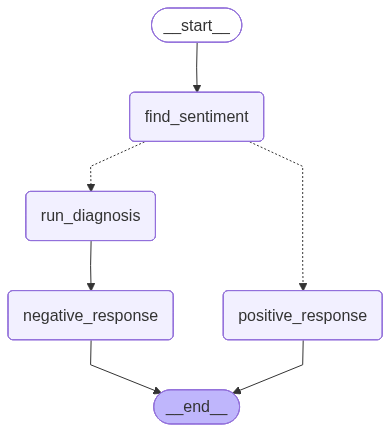

In [48]:
graph=StateGraph(ReviewState)

# add nodes 
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("positive_response",positive_response)
graph.add_node("negative_response",negative_response)
graph.add_node("run_diagnosis",run_diagnosis)


# add edges
graph.add_edge(START, "find_sentiment")

graph.add_conditional_edges(
    "find_sentiment",
    check_sentiment,
    {
        "positive_response": "positive_response",
        "run_diagnosis": "run_diagnosis"
    }
)

graph.add_edge("positive_response", END)

graph.add_edge("run_diagnosis", "negative_response")

graph.add_edge("negative_response", END)

# compile
graph.compile()